# Credit Risk Loan Analysis

**Tujuan:** Membangun model prediksi risiko kredit (credit scoring) untuk menentukan apakah seorang peminjam berpotensi **gagal bayar (default)** atau tidak, menggunakan data historis pinjaman dari Lending Club periode 2007-2014.

**Dataset:** `loan_data_2007_2014.csv` (466.285 baris, 74 kolom)

**Alur Kerja:**
1. **Data Understanding** - Memahami struktur data dan menentukan target variable
2. **Exploratory Data Analysis (EDA)** - Analisis visual dan statistik
3. **Data Preparation** - Cleaning, Feature Engineering, Encoding, Scaling
4. **Data Modelling** - Logistic Regression & Random Forest
5. **Evaluation** - Classification Report, Confusion Matrix, ROC-AUC

# 1. IMPORT LIBRARIES

In [2]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("Semua library berhasil di-import!")

Semua library berhasil di-import!


# 2. DATA UNDERSTANDING

## 2.1 Load Dataset

In [3]:
# Load dataset
df = pd.read_csv('loan_data_2007_2014.csv', index_col=0, low_memory=False)

print(f"Dataset Shape: {df.shape}")
print(f"Jumlah Baris : {df.shape[0]:,}")
print(f"Jumlah Kolom : {df.shape[1]}")
df.head()

Dataset Shape: (466285, 74)
Jumlah Baris : 466,285
Jumlah Kolom : 74


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.2 Eksplorasi Awal Data

In [4]:
# Informasi tipe data dan non-null count
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 466285 entries, 0 to 466284
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           466285 non-null  int64  
 1   member_id                    466285 non-null  int64  
 2   loan_amnt                    466285 non-null  int64  
 3   funded_amnt                  466285 non-null  int64  
 4   funded_amnt_inv              466285 non-null  float64
 5   term                         466285 non-null  object 
 6   int_rate                     466285 non-null  float64
 7   installment                  466285 non-null  float64
 8   grade                        466285 non-null  object 
 9   sub_grade                    466285 non-null  object 
 10  emp_title                    438697 non-null  object 
 11  emp_length                   445277 non-null  object 
 12  home_ownership               466285 non-null  object 
 13  annu

In [5]:
# Statistik deskriptif untuk kolom numerik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,466285.0,1.307973e+07,1.089371e+07,54734.00,3.639987e+06,1.010790e+07,2.073121e+07,3.809811e+07
member_id,466285.0,1.459766e+07,1.168237e+07,70473.00,4.379705e+06,1.194108e+07,2.300154e+07,4.086083e+07
loan_amnt,466285.0,1.431728e+04,8.286509e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt,466285.0,1.429180e+04,8.274371e+03,500.00,8.000000e+03,1.200000e+04,2.000000e+04,3.500000e+04
funded_amnt_inv,466285.0,1.422233e+04,8.297638e+03,0.00,8.000000e+03,1.200000e+04,1.995000e+04,3.500000e+04
int_rate,466285.0,1.382924e+01,4.357587e+00,5.42,1.099000e+01,1.366000e+01,1.649000e+01,2.606000e+01
installment,466285.0,4.320612e+02,2.434855e+02,15.67,2.566900e+02,3.798900e+02,5.665800e+02,1.409990e+03
annual_inc,466281.0,7.327738e+04,5.496357e+04,1896.00,4.500000e+04,6.300000e+04,8.896000e+04,7.500000e+06
dti,466285.0,1.721876e+01,7.851121e+00,0.00,1.136000e+01,1.687000e+01,2.278000e+01,3.999000e+01
delinq_2yrs,466256.0,2.846784e-01,7.973651e-01,0.00,0.000000e+00,0.000000e+00,0.000000e+00,2.900000e+01


In [6]:
# Cek tipe data
print("=== Tipe Data ===")
print(f"Numerik : {df.select_dtypes(include=[np.number]).shape[1]} kolom")
print(f"Kategori: {df.select_dtypes(include=['object']).shape[1]} kolom")

=== Tipe Data ===
Numerik : 52 kolom
Kategori: 22 kolom


## 2.3 Analisis Target Variable (`loan_status`)

In [7]:
# Distribusi loan_status
print("=== Distribusi loan_status ===")
status_counts = df['loan_status'].value_counts()
status_pct = df['loan_status'].value_counts(normalize=True) * 100

status_summary = pd.DataFrame({
    'Count': status_counts,
    'Percentage (%)': status_pct.round(2)
})
print(status_summary)

=== Distribusi loan_status ===
                                                     Count  Percentage (%)
loan_status                                                               
Current                                             224226           48.09
Fully Paid                                          184739           39.62
Charged Off                                          42475            9.11
Late (31-120 days)                                    6900            1.48
In Grace Period                                       3146            0.67
Does not meet the credit policy. Status:Fully Paid    1988            0.43
Late (16-30 days)                                     1218            0.26
Default                                                832            0.18
Does not meet the credit policy. Status:Charged...     761            0.16


## 2.4 Pembuatan Label (`bad_flag`)

Kita perlu mengubah `loan_status` menjadi variabel biner untuk klasifikasi:

| Status | Label | Keterangan |
|--------|-------|------------|
| Fully Paid | 0 (Good) | Pinjaman lunas |
| Current | 0 (Good) | Pinjaman masih berjalan lancar |
| Does not meet the credit policy. Status:Fully Paid | 0 (Good) | Lunas |
| **Charged Off** | **1 (Bad)** | Gagal bayar |
| **Default** | **1 (Bad)** | Gagal bayar |
| **Late (31-120 days)** | **1 (Bad)** | Telat bayar >30 hari |
| **Late (16-30 days)** | **1 (Bad)** | Telat bayar 16-30 hari |
| **In Grace Period** | **1 (Bad)** | Dalam masa tenggang |
| **Does not meet the credit policy. Status:Charged Off** | **1 (Bad)** | Gagal bayar |

In [8]:
# Definisi status pinjaman buruk
bad_status = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off',
    'Late (31-120 days)',
    'Late (16-30 days)',
    'In Grace Period'
]

# Buat kolom target: bad_flag (1 = Bad, 0 = Good)
df['bad_flag'] = np.where(df['loan_status'].isin(bad_status), 1, 0)

print("=== Distribusi bad_flag ===")
print(df['bad_flag'].value_counts())
print(f"\nBad Loan Rate: {df['bad_flag'].mean()*100:.2f}%")
print(f"Good Loan Rate: {(1-df['bad_flag'].mean())*100:.2f}%")

=== Distribusi bad_flag ===
bad_flag
0    410953
1     55332
Name: count, dtype: int64

Bad Loan Rate: 11.87%
Good Loan Rate: 88.13%


## 2.5 Identifikasi & Penghapusan Kolom

Kolom yang harus dihapus dikategorikan sebagai berikut:

1. **Kolom Identitas & Teks Bebas** - Tidak memiliki nilai prediktif (`id`, `member_id`, `url`, `desc`, `emp_title`, `title`, `zip_code`)
2. **Kolom Data Leakage** - Informasi yang hanya tersedia **setelah** pinjaman disetujui, sehingga tidak bisa digunakan untuk prediksi (`funded_amnt`, `total_pymnt`, `recoveries`, dll.)
3. **Kolom All-Null / Konstan** - Kolom yang seluruh nilainya null atau bernilai sama (`annual_inc_joint`, `open_acc_6m`, `policy_code`, dll.)
4. **Kolom Redundan** - `sub_grade` (redundan dengan `grade`), `loan_status` (sudah dikonversi ke `bad_flag`)

> **⚠️ Data Leakage** adalah kesalahan paling kritis dalam pemodelan prediksi. Menggunakan informasi masa depan untuk memprediksi akan menghasilkan model yang tampak bagus saat training, namun gagal total di dunia nyata.

In [9]:
# 1. Kolom identitas dan teks bebas
id_text_cols = ['id', 'member_id', 'url', 'desc', 'emp_title', 'title', 'zip_code']

# 2. Kolom DATA LEAKAGE (informasi post-origination / setelah pinjaman disetujui)
leakage_cols = [
    'funded_amnt', 'funded_amnt_inv',          # jumlah yang didanai (post-approval)
    'out_prncp', 'out_prncp_inv',               # sisa pokok pinjaman
    'total_pymnt', 'total_pymnt_inv',           # total pembayaran diterima
    'total_rec_prncp', 'total_rec_int',         # pokok & bunga diterima
    'total_rec_late_fee',                       # biaya keterlambatan diterima
    'recoveries', 'collection_recovery_fee',    # recovery post charge-off
    'last_pymnt_d', 'last_pymnt_amnt',          # info pembayaran terakhir
    'next_pymnt_d',                             # tanggal pembayaran berikutnya
    'last_credit_pull_d',                       # tanggal credit pull terakhir
    'initial_list_status',                      # status listing
    'pymnt_plan',                               # rencana pembayaran
]

# 3. Kolom yang semua null (0 non-null) atau konstan
all_null_const_cols = [
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m',
    'mths_since_rcnt_il', 'total_bal_il', 'il_util',
    'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
    'inq_fi', 'total_cu_tl', 'inq_last_12m',
    'policy_code',        # konstan (semua = 1)
    'application_type',   # hampir semua = INDIVIDUAL
]

# 4. Kolom redundan dan kolom yang sudah dikonversi
other_drop_cols = [
    'sub_grade',   # redundan dengan grade
    'loan_status', # sudah dikonversi ke bad_flag
    'addr_state',  # terlalu banyak kategori (50 state)
    'issue_d',     # tanggal issue (post-origination)
]

# Gabungkan semua kolom yang akan di-drop
cols_to_drop = id_text_cols + leakage_cols + all_null_const_cols + other_drop_cols

# Drop kolom
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"Shape setelah drop kolom: {df.shape}")
print(f"\nKolom tersisa ({len(df.columns)}):")
for i, col in enumerate(df.columns.tolist()):
    dtype = df[col].dtype
    non_null = df[col].notna().sum()
    print(f"  {i+1:2d}. {col:<35s} | {str(dtype):<10s} | Non-null: {non_null:,}")

Shape setelah drop kolom: (466285, 28)

Kolom tersisa (28):
   1. loan_amnt                           | int64      | Non-null: 466,285
   2. term                                | object     | Non-null: 466,285
   3. int_rate                            | float64    | Non-null: 466,285
   4. installment                         | float64    | Non-null: 466,285
   5. grade                               | object     | Non-null: 466,285
   6. emp_length                          | object     | Non-null: 445,277
   7. home_ownership                      | object     | Non-null: 466,285
   8. annual_inc                          | float64    | Non-null: 466,281
   9. verification_status                 | object     | Non-null: 466,285
  10. purpose                             | object     | Non-null: 466,285
  11. dti                                 | float64    | Non-null: 466,285
  12. delinq_2yrs                         | float64    | Non-null: 466,256
  13. earliest_cr_line                  

# 3. EXPLORATORY DATA ANALYSIS (EDA)

## 3.1 Distribusi Target Variable

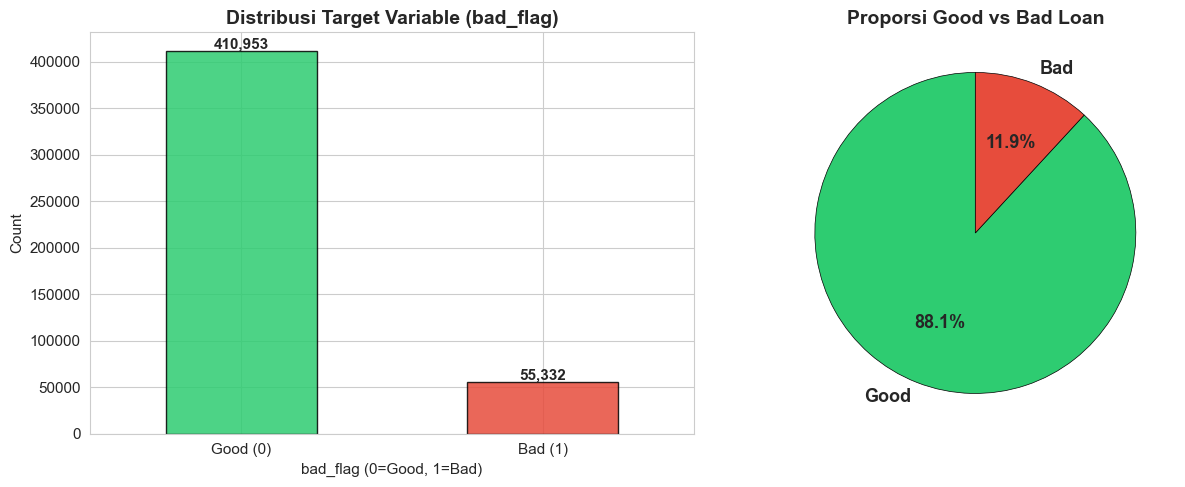

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#2ecc71', '#e74c3c']

# Bar chart
counts = df['bad_flag'].value_counts()
counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Distribusi Target Variable (bad_flag)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('bad_flag (0=Good, 1=Bad)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Good (0)', 'Bad (1)'], rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v + 3000, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# Pie chart
counts.plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=colors, labels=['Good', 'Bad'],
    startangle=90, textprops={'fontsize': 13, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
axes[1].set_title('Proporsi Good vs Bad Loan', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.2 Analisis Missing Values

In [11]:
# Hitung missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("=== Kolom dengan Missing Values ===")
print(missing_df)
print(f"\nTotal kolom dengan missing: {len(missing_df)} dari {len(df.columns)}")

=== Kolom dengan Missing Values ===
                             Missing Count  Missing %
mths_since_last_record              403647      86.57
mths_since_last_major_derog         367311      78.77
mths_since_last_delinq              250351      53.69
total_rev_hi_lim                     70276      15.07
tot_cur_bal                          70276      15.07
tot_coll_amt                         70276      15.07
emp_length                           21008       4.51
revol_util                             340       0.07
collections_12_mths_ex_med             145       0.03
open_acc                                29       0.01
total_acc                               29       0.01
inq_last_6mths                          29       0.01
acc_now_delinq                          29       0.01
earliest_cr_line                        29       0.01
delinq_2yrs                             29       0.01
pub_rec                                 29       0.01
annual_inc                               4    

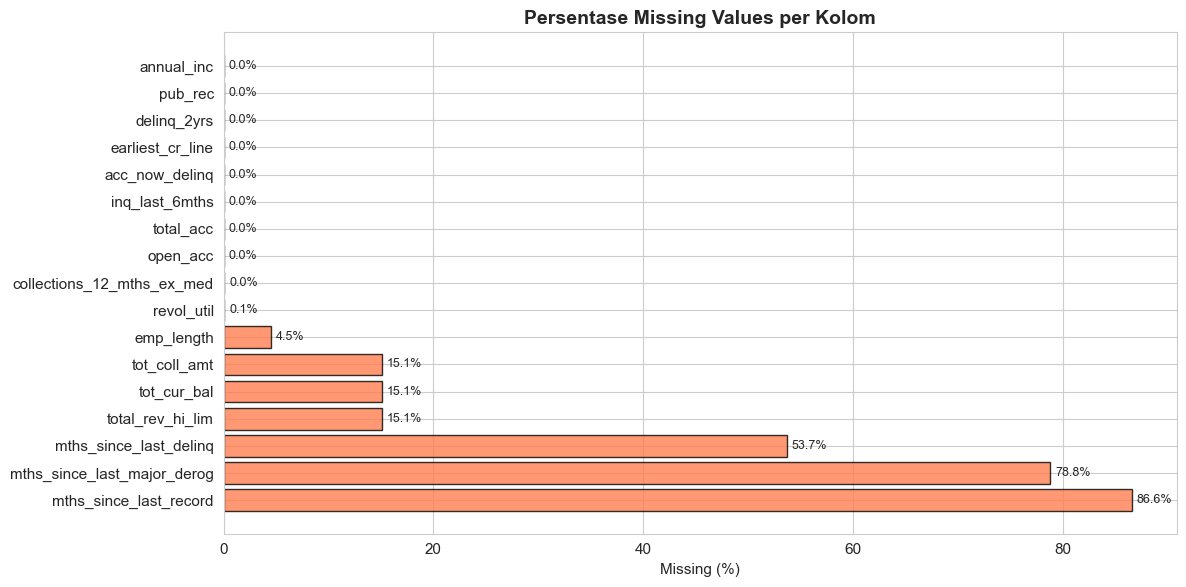

In [12]:
# Visualisasi missing values
if len(missing_df) > 0:
    plt.figure(figsize=(12, 6))
    bars = plt.barh(missing_df.index, missing_df['Missing %'], color='coral', edgecolor='black', alpha=0.8)
    plt.title('Persentase Missing Values per Kolom', fontsize=14, fontweight='bold')
    plt.xlabel('Missing (%)')
    for bar, pct in zip(bars, missing_df['Missing %']):
        plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{pct:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('02_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3.3 Distribusi Fitur Numerik

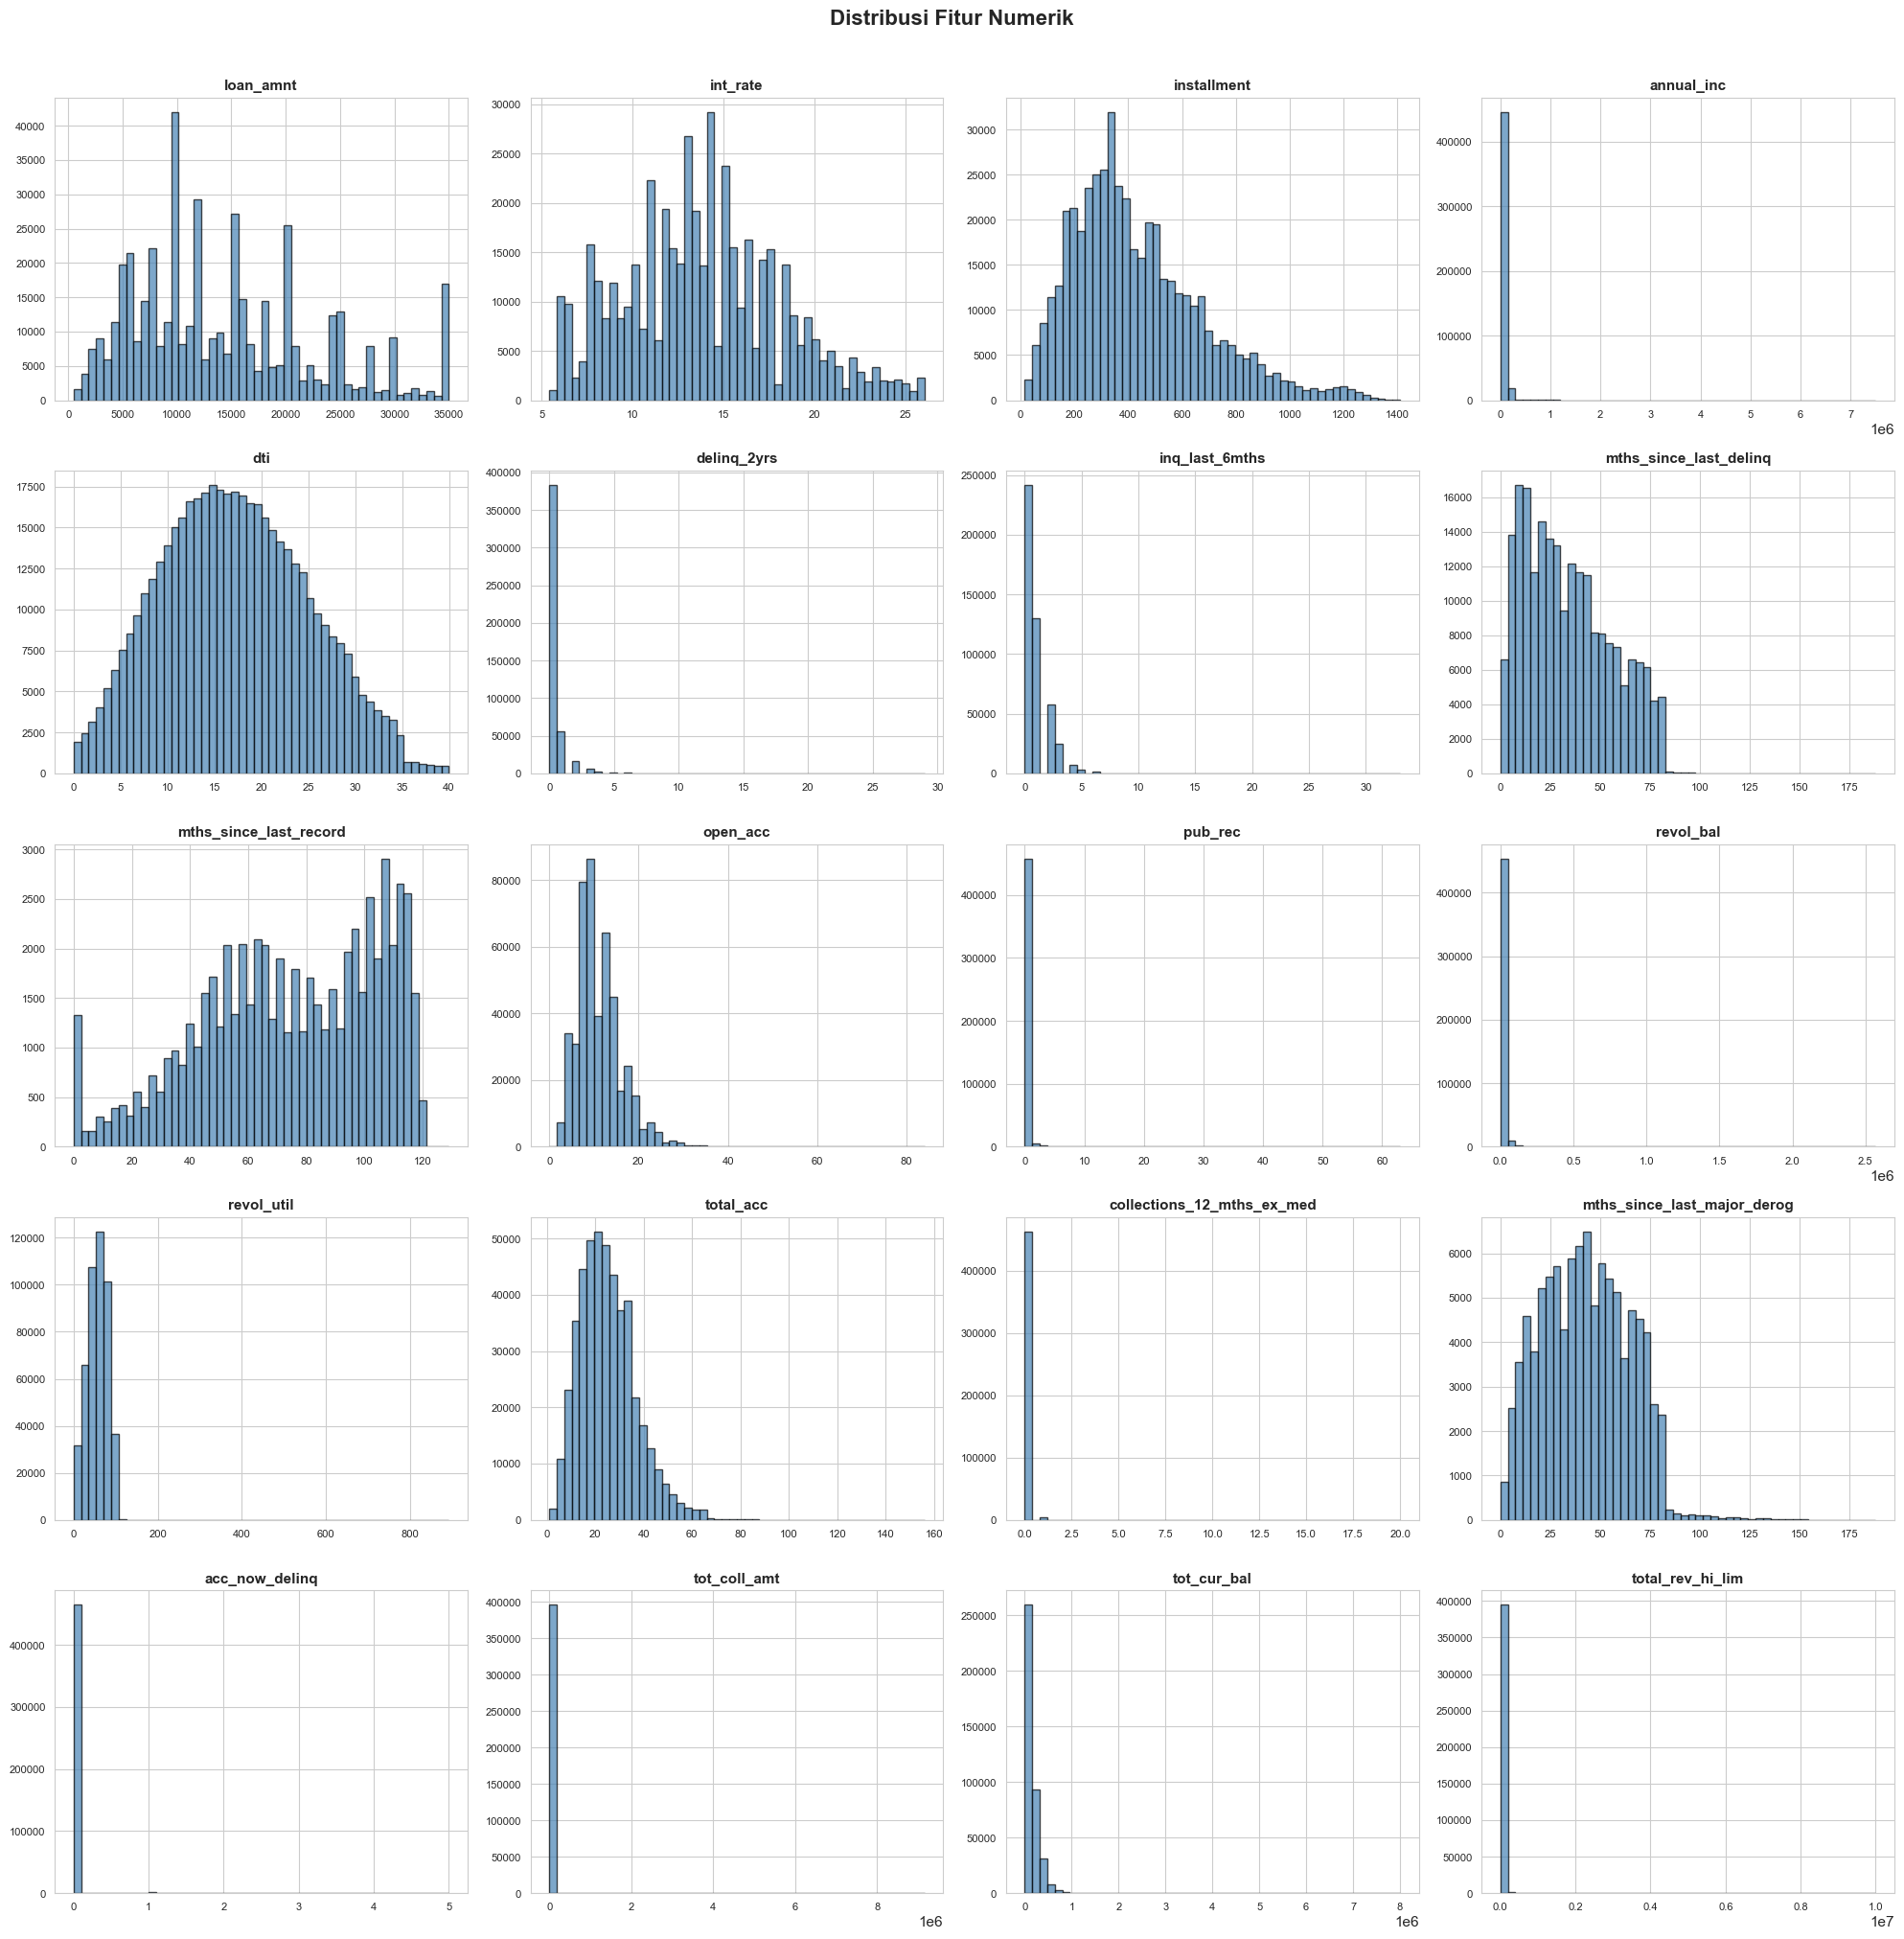

In [13]:
# Distribusi fitur numerik
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'bad_flag']

n_plots = min(len(num_cols), 20)
n_cols_plot = 4
n_rows_plot = (n_plots + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(20, n_rows_plot * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols[:n_plots]):
    df[col].hist(bins=50, ax=axes[i], color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.4 Analisis Bivariat terhadap Target

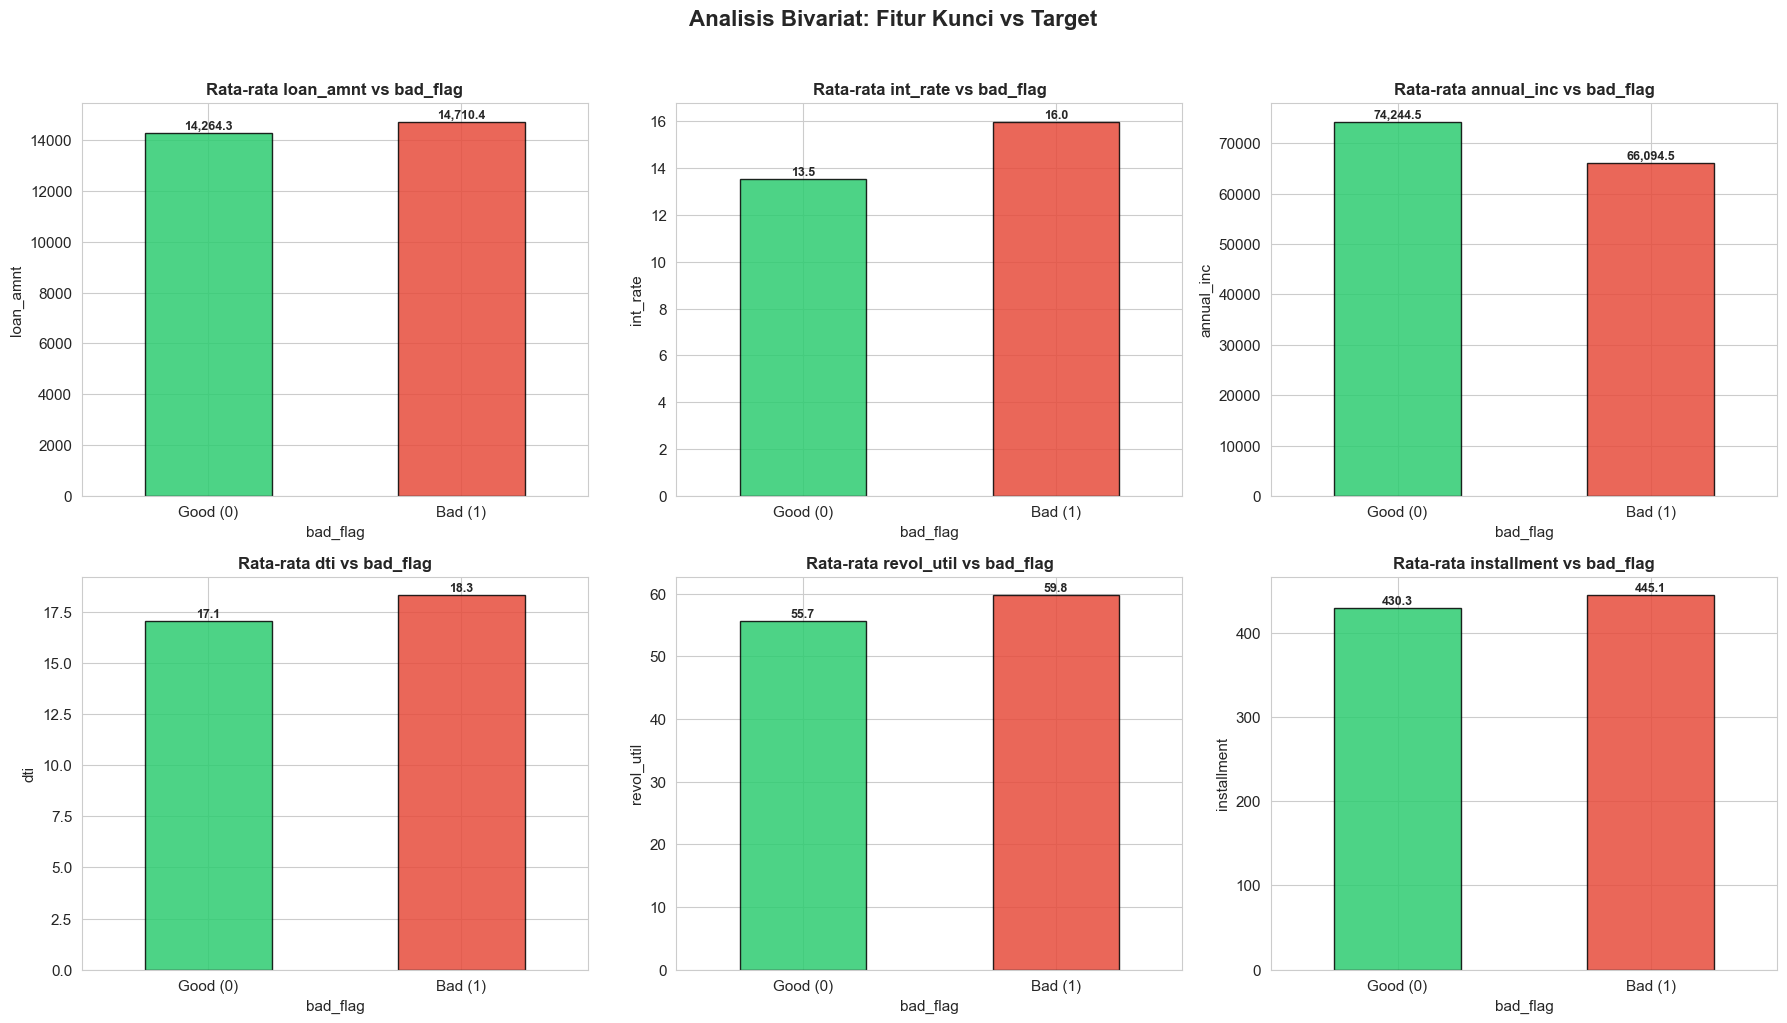

In [14]:
# Analisis bivariat: fitur numerik kunci vs target
key_features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_util', 'installment']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    means = df.groupby('bad_flag')[col].mean()
    bars = means.plot(kind='bar', ax=axes[i], color=colors, edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Rata-rata {col} vs bad_flag', fontsize=12, fontweight='bold')
    axes[i].set_xticklabels(['Good (0)', 'Bad (1)'], rotation=0)
    axes[i].set_ylabel(col)
    for j, v in enumerate(means):
        axes[i].text(j, v * 1.01, f'{v:,.1f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Analisis Bivariat: Fitur Kunci vs Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('04_bivariate_numerical.png', dpi=150, bbox_inches='tight')
plt.show()

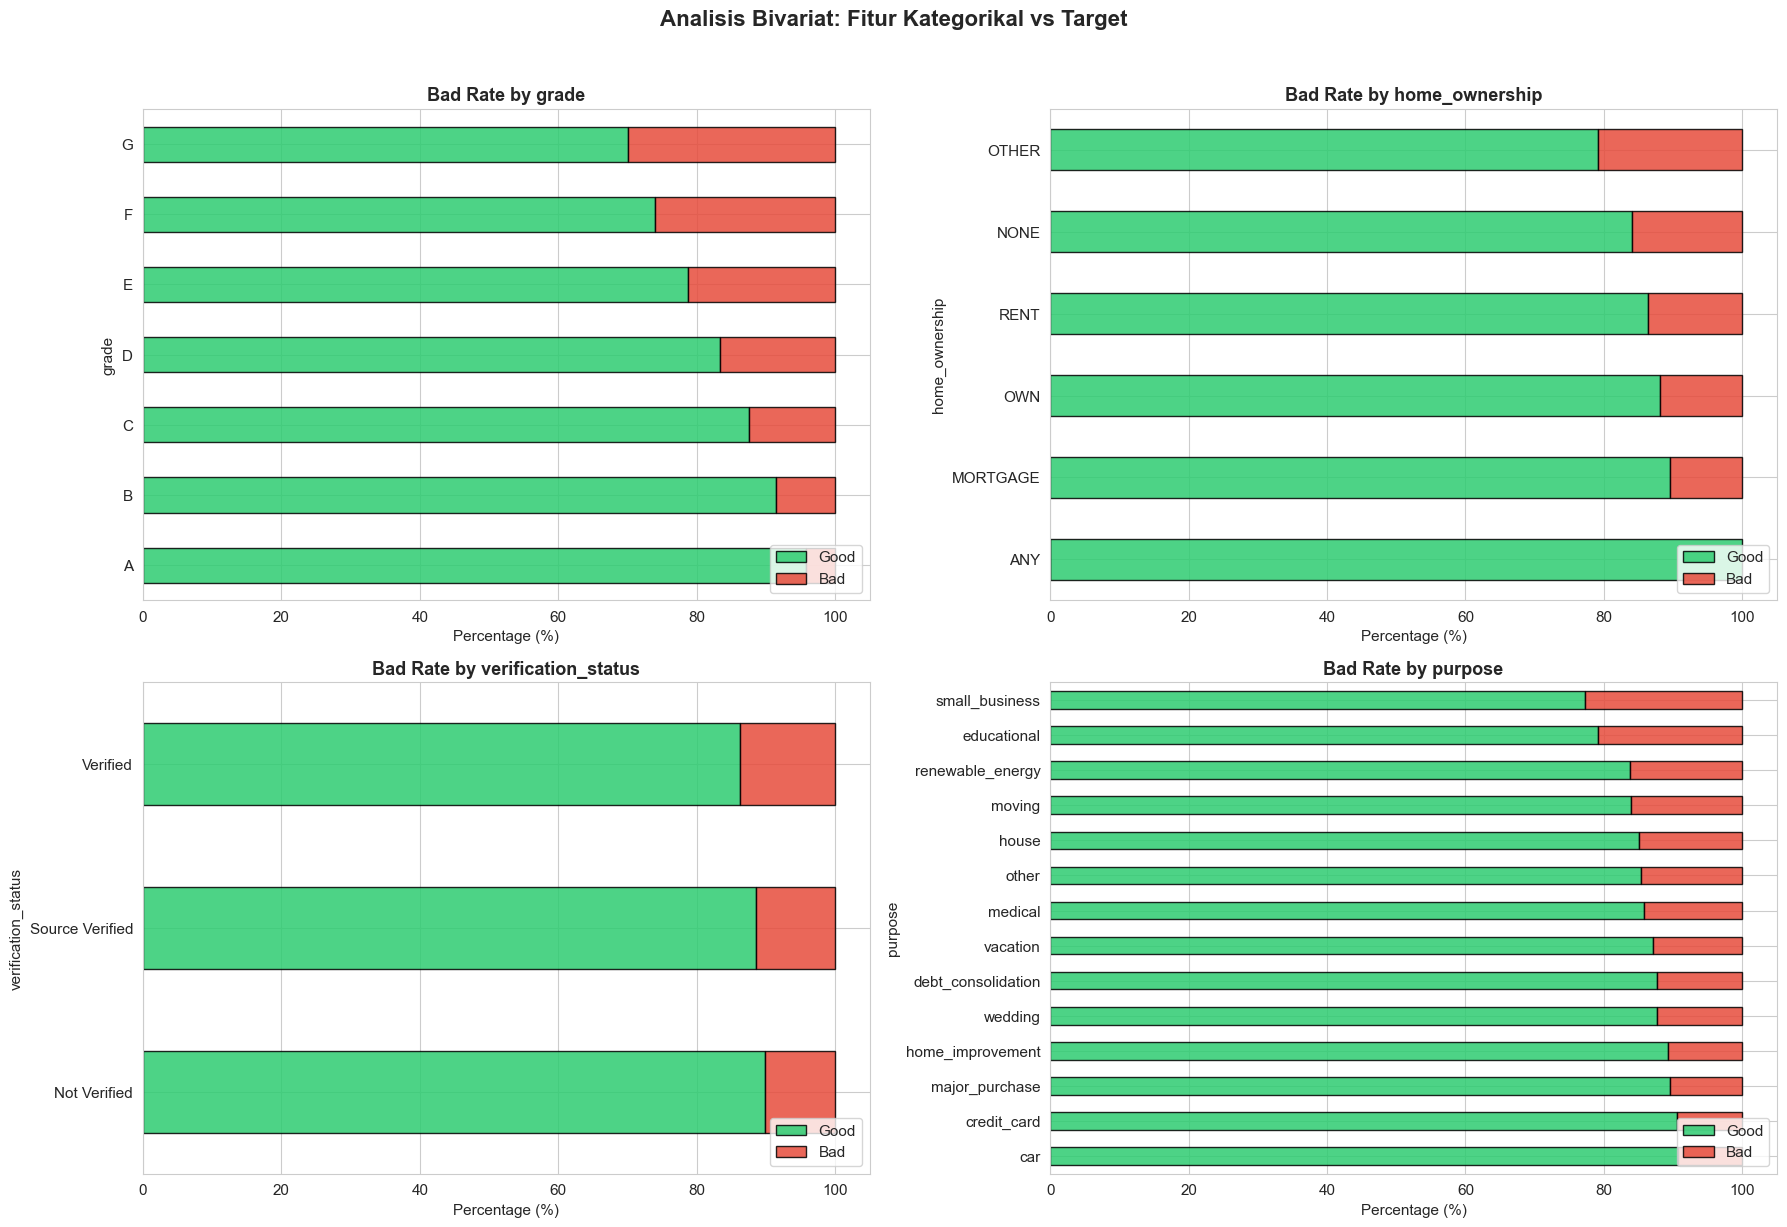

In [15]:
# Analisis bivariat: fitur kategorikal vs target (Bad Rate)
cat_cols_eda = ['grade', 'home_ownership', 'verification_status', 'purpose']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols_eda):
    ct = pd.crosstab(df[col], df['bad_flag'], normalize='index') * 100
    ct.columns = ['Good %', 'Bad %']
    ct.sort_values('Bad %', ascending=True).plot(
        kind='barh', stacked=True, ax=axes[i], color=colors, edgecolor='black', alpha=0.85
    )
    axes[i].set_title(f'Bad Rate by {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Percentage (%)')
    axes[i].legend(['Good', 'Bad'], loc='lower right')

plt.suptitle('Analisis Bivariat: Fitur Kategorikal vs Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('05_bivariate_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.5 Matriks Korelasi

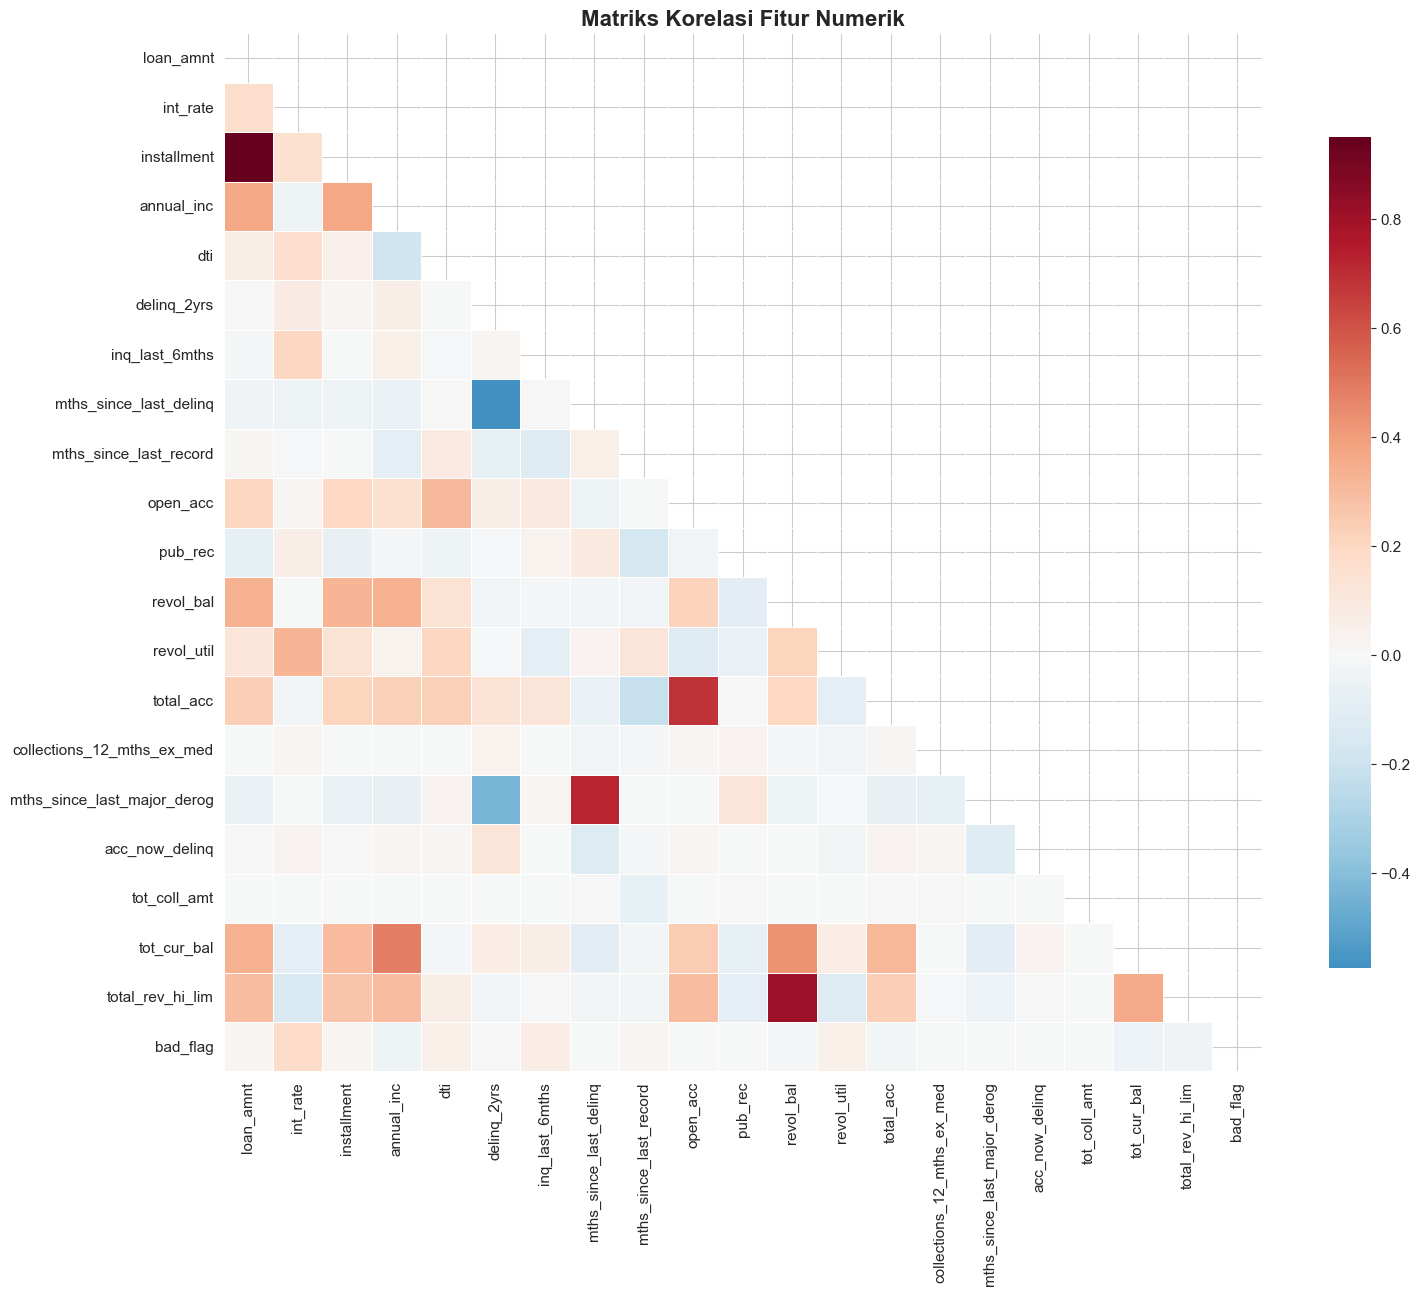

In [16]:
# Korelasi antar fitur numerik
plt.figure(figsize=(16, 13))
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            linewidths=0.5, annot=False, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Matriks Korelasi Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

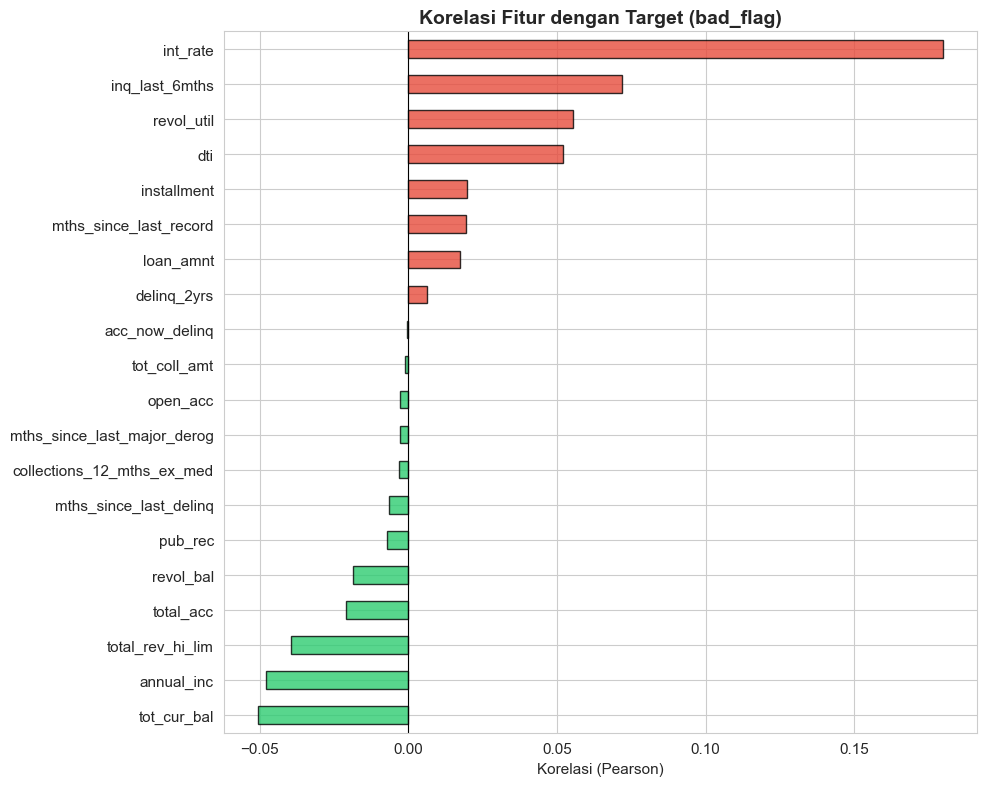


Top 10 fitur paling berkorelasi (absolut) dengan bad_flag:
int_rate                  0.1798
inq_last_6mths            0.0718
revol_util                0.0553
dti                       0.0521
tot_cur_bal               0.0507
annual_inc                0.0480
total_rev_hi_lim          0.0395
total_acc                 0.0210
installment               0.0196
mths_since_last_record    0.0195
Name: bad_flag, dtype: float64


In [17]:
# Korelasi fitur terhadap target (bad_flag)
target_corr = corr['bad_flag'].drop('bad_flag').sort_values()

plt.figure(figsize=(10, 8))
bar_colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in target_corr]
target_corr.plot(kind='barh', color=bar_colors, edgecolor='black', alpha=0.8)
plt.title('Korelasi Fitur dengan Target (bad_flag)', fontsize=14, fontweight='bold')
plt.xlabel('Korelasi (Pearson)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('07_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 fitur paling berkorelasi (absolut) dengan bad_flag:")
print(target_corr.abs().sort_values(ascending=False).head(10).round(4))

# 4. DATA PREPARATION

## 4.1 Handling Missing Values

Strategi penanganan missing values:
- **Missing kecil (<1%)** → Imputasi dengan median (numerik) atau modus (kategorikal)
- **Missing sedang (1-20%)** → Imputasi dengan median + analisis dampak
- **Missing besar (>50%)** untuk kolom `mths_since_*` → Missing berarti **tidak ada kejadian** (misal: tidak pernah telat bayar), jadi buat **binary flag** dan isi missing dengan nilai besar (999)

In [18]:
print("=== Missing Values SEBELUM Handling ===")
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum():,}")

=== Missing Values SEBELUM Handling ===
emp_length                      21008
annual_inc                          4
delinq_2yrs                        29
earliest_cr_line                   29
inq_last_6mths                     29
mths_since_last_delinq         250351
mths_since_last_record         403647
open_acc                           29
pub_rec                            29
revol_util                        340
total_acc                          29
collections_12_mths_ex_med        145
mths_since_last_major_derog    367311
acc_now_delinq                     29
tot_coll_amt                    70276
tot_cur_bal                     70276
total_rev_hi_lim                70276
dtype: int64

Total missing values: 1,253,837


In [19]:
# 1. annual_inc (4 missing) → isi dengan median
df['annual_inc'].fillna(df['annual_inc'].median(), inplace=True)

# 2. Kolom numerik dengan missing kecil → isi dengan 0 (artinya tidak ada kejadian)
zero_fill_cols = [
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
    'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq'
]
for col in zero_fill_cols:
    df[col].fillna(0, inplace=True)

# 3. revol_util → isi dengan median
df['revol_util'].fillna(df['revol_util'].median(), inplace=True)

# 4. Kolom "months since" dengan missing BESAR
#    Missing = tidak pernah terjadi kejadian tersebut → buat binary flag + isi dengan 999
mths_cols = ['mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog']
for col in mths_cols:
    flag_name = f'flag_{col}'
    df[flag_name] = np.where(df[col].isnull(), 0, 1)  # 0 = tidak pernah, 1 = pernah
    df[col].fillna(999, inplace=True)
    print(f"Kolom '{col}': flag '{flag_name}' dibuat, missing diisi 999")

# 5. tot_coll_amt, tot_cur_bal, total_rev_hi_lim
df['tot_coll_amt'].fillna(0, inplace=True)
df['tot_cur_bal'].fillna(df['tot_cur_bal'].median(), inplace=True)
df['total_rev_hi_lim'].fillna(df['total_rev_hi_lim'].median(), inplace=True)

print("\n=== Missing Values SESUDAH Handling ===")
missing_after = df.isnull().sum()
print(missing_after[missing_after > 0])
if missing_after.sum() == 0:
    print("\nTidak ada kolom numerik yang masih memiliki missing values (kecuali kategorikal yang belum diproses).")

Kolom 'mths_since_last_delinq': flag 'flag_mths_since_last_delinq' dibuat, missing diisi 999
Kolom 'mths_since_last_record': flag 'flag_mths_since_last_record' dibuat, missing diisi 999
Kolom 'mths_since_last_major_derog': flag 'flag_mths_since_last_major_derog' dibuat, missing diisi 999

=== Missing Values SESUDAH Handling ===
emp_length          21008
earliest_cr_line       29
dtype: int64


## 4.2 Feature Engineering

Mengubah kolom kategorikal dan tanggal menjadi format numerik:
- `term` → ekstrak angka bulan (36 / 60)
- `emp_length` → mapping ke numerik (0-10)
- `grade` → ordinal encoding (A=1, B=2, ..., G=7)
- `earliest_cr_line` → hitung bulan sejak tanggal tersebut
- `home_ownership` → konsolidasi kategori langka

In [20]:
# 1. TERM: " 36 months" / " 60 months" → 36 / 60
df['term_int'] = df['term'].str.extract(r'(\d+)').astype(int)
df.drop('term', axis=1, inplace=True)
print("1. term → term_int")
print(f"   Unique values: {sorted(df['term_int'].unique())}")

# 2. EMP_LENGTH: mapping ke numerik
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}
df['emp_length_int'] = df['emp_length'].map(emp_map)
df['emp_length_int'].fillna(df['emp_length_int'].median(), inplace=True)
df.drop('emp_length', axis=1, inplace=True)
print("\n2. emp_length → emp_length_int")
print(f"   Unique values: {sorted(df['emp_length_int'].unique())}")

# 3. GRADE: ordinal encoding
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade'] = df['grade'].map(grade_map)
print("\n3. grade → ordinal (A=1, ..., G=7)")
print(f"   Unique values: {sorted(df['grade'].unique())}")

# 4. EARLIEST_CR_LINE: konversi ke "bulan sejak" tanggal referensi
df['earliest_cr_line_date'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%y', errors='coerce')

# Fix tanggal yang terparsing ke abad 21 padahal seharusnya abad 20
# Contoh: "Sep-62" → 2062-09-01 seharusnya 1962-09-01
mask_future = df['earliest_cr_line_date'] > pd.Timestamp('2020-01-01')
df.loc[mask_future, 'earliest_cr_line_date'] -= pd.DateOffset(years=100)

reference_date = pd.Timestamp('2017-12-01')
df['mths_since_earliest_cr_line'] = (
    (reference_date.year - df['earliest_cr_line_date'].dt.year) * 12 +
    (reference_date.month - df['earliest_cr_line_date'].dt.month)
)
df['mths_since_earliest_cr_line'].fillna(df['mths_since_earliest_cr_line'].median(), inplace=True)
df.drop(['earliest_cr_line', 'earliest_cr_line_date'], axis=1, inplace=True, errors='ignore')
print("\n4. earliest_cr_line → mths_since_earliest_cr_line")
print(f"   Mean: {df['mths_since_earliest_cr_line'].mean():.0f} bulan")
print(f"   Min : {df['mths_since_earliest_cr_line'].min():.0f}, Max: {df['mths_since_earliest_cr_line'].max():.0f}")

# 5. HOME_OWNERSHIP: konsolidasi kategori langka
df['home_ownership'] = df['home_ownership'].replace({'NONE': 'OTHER', 'ANY': 'OTHER'})
print("\n5. home_ownership: 'NONE' & 'ANY' digabung ke 'OTHER'")
print(f"   Unique values: {df['home_ownership'].unique()}")

print(f"\n=== Shape setelah Feature Engineering: {df.shape} ===")

1. term → term_int
   Unique values: [36, 60]

2. emp_length → emp_length_int
   Unique values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

3. grade → ordinal (A=1, ..., G=7)
   Unique values: [1, 2, 3, 4, 5, 6, 7]

4. earliest_cr_line → mths_since_earliest_cr_line
   Mean: 242 bulan
   Min : 73, Max: 887

5. home_ownership: 'NONE' & 'ANY' digabung ke 'OTHER'
   Unique values: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']

=== Shape setelah Feature Engineering: (466285, 31) ===


## 4.3 Encoding Variabel Kategorikal

Menggunakan **One-Hot Encoding** (`pd.get_dummies`) untuk variabel kategorikal:
- `home_ownership` (RENT, OWN, MORTGAGE, OTHER)
- `verification_status` (Verified, Source Verified, Not Verified)
- `purpose` (14 kategori)

Parameter `drop_first=True` untuk menghindari **multicollinearity** (dummy variable trap) pada Logistic Regression.

In [21]:
# Kolom kategorikal yang akan di-encode
cat_cols = ['home_ownership', 'verification_status', 'purpose']

print("=== Kolom Kategorikal yang akan di-encode ===")
for col in cat_cols:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts())

# One-Hot Encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

print(f"\n=== Shape setelah encoding: {df.shape} ===")
print(f"\nSemua kolom sekarang ({len(df.columns)}):")
for i, col in enumerate(df.columns.tolist()):
    print(f"  {i+1:2d}. {col}")

=== Kolom Kategorikal yang akan di-encode ===

home_ownership (4 unique):
home_ownership
MORTGAGE    235875
RENT        188473
OWN          41704
OTHER          233
Name: count, dtype: int64

verification_status (3 unique):
verification_status
Verified           168055
Source Verified    149993
Not Verified       148237
Name: count, dtype: int64

purpose (14 unique):
purpose
debt_consolidation    274195
credit_card           104157
home_improvement       26537
other                  23690
major_purchase          9828
small_business          7013
car                     5397
medical                 4602
moving                  2994
vacation                2487
wedding                 2343
house                   2269
educational              422
renewable_energy         351
Name: count, dtype: int64

=== Shape setelah encoding: (466285, 46) ===

Semua kolom sekarang (46):
   1. loan_amnt
   2. int_rate
   3. installment
   4. grade
   5. annual_inc
   6. dti
   7. delinq_2yrs
   8. inq_

## 4.4 Verifikasi Final & Cek Missing Values

Sebelum masuk ke tahap modelling, pastikan:
- Tidak ada missing values
- Semua fitur bertipe numerik
- Target variable sudah siap

In [22]:
# Verifikasi final
print("=== VERIFIKASI FINAL ===")
print(f"Shape: {df.shape}")
print(f"Missing values total: {df.isnull().sum().sum()}")
print(f"Tipe data:\n{df.dtypes.value_counts()}")

# Jika masih ada missing, drop rows
if df.isnull().sum().sum() > 0:
    print(f"\nMasih ada {df.isnull().sum().sum()} missing values. Drop rows...")
    df.dropna(inplace=True)
    print(f"Shape setelah drop: {df.shape}")
else:
    print("\n✓ Tidak ada missing values!")

print(f"\nDistribusi target setelah preprocessing:")
print(df['bad_flag'].value_counts())
print(f"Bad Rate: {df['bad_flag'].mean()*100:.2f}%")

=== VERIFIKASI FINAL ===
Shape: (466285, 46)
Missing values total: 0
Tipe data:
int32      23
float64    20
int64       3
Name: count, dtype: int64

✓ Tidak ada missing values!

Distribusi target setelah preprocessing:
bad_flag
0    410953
1     55332
Name: count, dtype: int64
Bad Rate: 11.87%


## 4.5 Train-Test Split

In [23]:
# Pisahkan fitur (X) dan target (y)
X = df.drop('bad_flag', axis=1)
y = df['bad_flag']

# Split data: 80% training, 20% testing (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=== Train-Test Split ===")
print(f"Training set : {X_train.shape}")
print(f"Testing set  : {X_test.shape}")
print(f"\nDistribusi target di TRAINING set:")
print(y_train.value_counts())
print(f"Bad Rate: {y_train.mean()*100:.2f}%")
print(f"\nDistribusi target di TESTING set:")
print(y_test.value_counts())
print(f"Bad Rate: {y_test.mean()*100:.2f}%")

=== Train-Test Split ===
Training set : (373028, 45)
Testing set  : (93257, 45)

Distribusi target di TRAINING set:
bad_flag
0    328762
1     44266
Name: count, dtype: int64
Bad Rate: 11.87%

Distribusi target di TESTING set:
bad_flag
0    82191
1    11066
Name: count, dtype: int64
Bad Rate: 11.87%


## 4.6 Feature Scaling

Menggunakan **StandardScaler** (z-score normalization) agar semua fitur memiliki skala yang sama.
Penting terutama untuk **Logistic Regression** yang sensitif terhadap perbedaan skala fitur.

> **Catatan:** `fit_transform()` hanya pada training set, `transform()` pada testing set untuk menghindari data leakage.

In [24]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Feature Scaling selesai!")
print(f"\nContoh data setelah scaling (5 baris pertama):")
X_train_scaled.head()

Feature Scaling selesai!

Contoh data setelah scaling (5 baris pertama):


,loan_amnt,int_rate,installment,grade,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
40390,-0.858390,0.686344,-1.041389,1.651982,2.110946,0.611479,-0.356562,2.927320,0.928511,0.393858,...,-0.245522,-0.069575,-0.146817,-0.100268,-0.0802,-0.230731,-0.027941,-0.123768,-0.073512,-0.070771
24349,-0.279703,-0.794582,-0.176378,-0.617400,0.663708,-1.490946,-0.356562,-0.735545,0.928511,0.393858,...,4.072962,-0.069575,-0.146817,-0.100268,-0.0802,-0.230731,-0.027941,-0.123768,-0.073512,-0.070771
420905,0.202535,-0.191666,0.437727,-0.617400,0.754093,-0.197146,-0.356562,2.011604,0.928511,0.393858,...,-0.245522,-0.069575,-0.146817,-0.100268,-0.0802,-0.230731,-0.027941,-0.123768,-0.073512,-0.070771
30522,-0.882502,-1.447931,-0.879366,-1.373860,-0.805383,-0.208607,-0.356562,-0.735545,0.928511,0.393858,...,-0.245522,-0.069575,-0.146817,-0.100268,-0.0802,-0.230731,-0.027941,-0.123768,-0.073512,-0.070771
285358,-0.858390,-0.306289,-0.784784,-0.617400,-0.277115,-0.082538,-0.356562,-0.735545,-1.088620,0.393858,...,-0.245522,-0.069575,-0.146817,-0.100268,-0.0802,-0.230731,-0.027941,-0.123768,-0.073512,-0.070771


# 5. DATA MODELLING

## 5.1 Model 1: Logistic Regression

Logistic Regression dipilih karena:
- Interpretable (mudah diinterpretasi)
- Cocok untuk binary classification
- Baseline model yang baik untuk credit scoring
- `class_weight='balanced'` untuk menangani ketidakseimbangan kelas

In [25]:
print("=" * 65)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 65)

# Training model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    solver='lbfgs'
)
lr_model.fit(X_train_scaled, y_train)

# Prediksi
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)
y_test_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluasi
print("\n--- Training Set ---")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred_lr):.4f}")

print("\n--- Testing Set ---")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred_lr):.4f}")
print(f"F1-Score : {f1_score(y_test, y_test_pred_lr):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_proba_lr):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_test_pred_lr, target_names=['Good (0)', 'Bad (1)']))

MODEL 1: LOGISTIC REGRESSION

--- Training Set ---
Accuracy: 0.6283

--- Testing Set ---
Accuracy : 0.6274
Precision: 0.1848
Recall   : 0.6275
F1-Score : 0.2856
ROC-AUC  : 0.6776

--- Classification Report ---
              precision    recall  f1-score   support

    Good (0)       0.93      0.63      0.75     82191
     Bad (1)       0.18      0.63      0.29     11066

    accuracy                           0.63     93257
   macro avg       0.56      0.63      0.52     93257
weighted avg       0.84      0.63      0.69     93257



## 5.2 Model 2: Random Forest Classifier

Random Forest dipilih karena:
- Mampu menangkap hubungan non-linear
- Lebih robust terhadap outlier
- Memberikan informasi **Feature Importance**
- `class_weight='balanced'` untuk menangani imbalanced data

In [26]:
print("=" * 65)
print("MODEL 2: RANDOM FOREST CLASSIFIER")
print("=" * 65)

# Training model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train)

# Prediksi
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)
y_test_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluasi
print("\n--- Training Set ---")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred_rf):.4f}")

print("\n--- Testing Set ---")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred_rf):.4f}")
print(f"F1-Score : {f1_score(y_test, y_test_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_proba_rf):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_test_pred_rf, target_names=['Good (0)', 'Bad (1)']))

MODEL 2: RANDOM FOREST CLASSIFIER

--- Training Set ---
Accuracy: 0.6584

--- Testing Set ---
Accuracy : 0.6314
Precision: 0.1892
Recall   : 0.6412
F1-Score : 0.2922
ROC-AUC  : 0.6902

--- Classification Report ---
              precision    recall  f1-score   support

    Good (0)       0.93      0.63      0.75     82191
     Bad (1)       0.19      0.64      0.29     11066

    accuracy                           0.63     93257
   macro avg       0.56      0.64      0.52     93257
weighted avg       0.84      0.63      0.70     93257



# 6. EVALUASI MODEL

## 6.1 Confusion Matrix

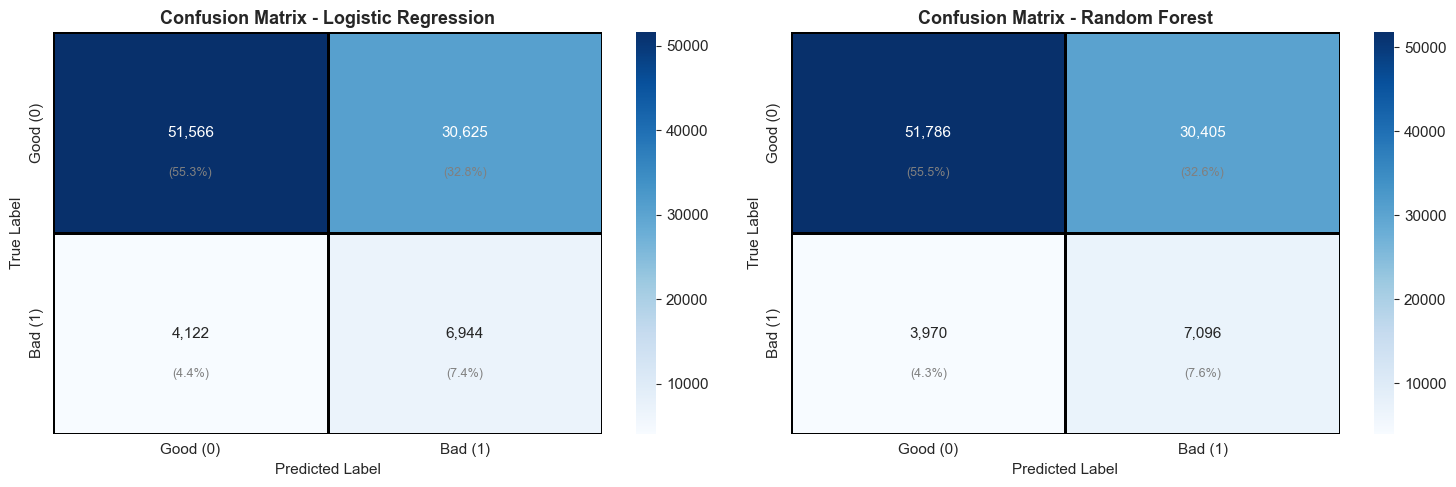

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

models = [
    (y_test_pred_lr, 'Logistic Regression'),
    (y_test_pred_rf, 'Random Forest')
]

for ax, (y_pred, title) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Good (0)', 'Bad (1)'],
                yticklabels=['Good (0)', 'Bad (1)'],
                linewidths=1, linecolor='black')
    ax.set_title(f'Confusion Matrix - {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

    # Annotate with percentages
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            pct = cm[i][j] / total * 100
            ax.text(j + 0.5, i + 0.7, f'({pct:.1f}%)',
                    ha='center', va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('08_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.2 ROC-AUC Curve

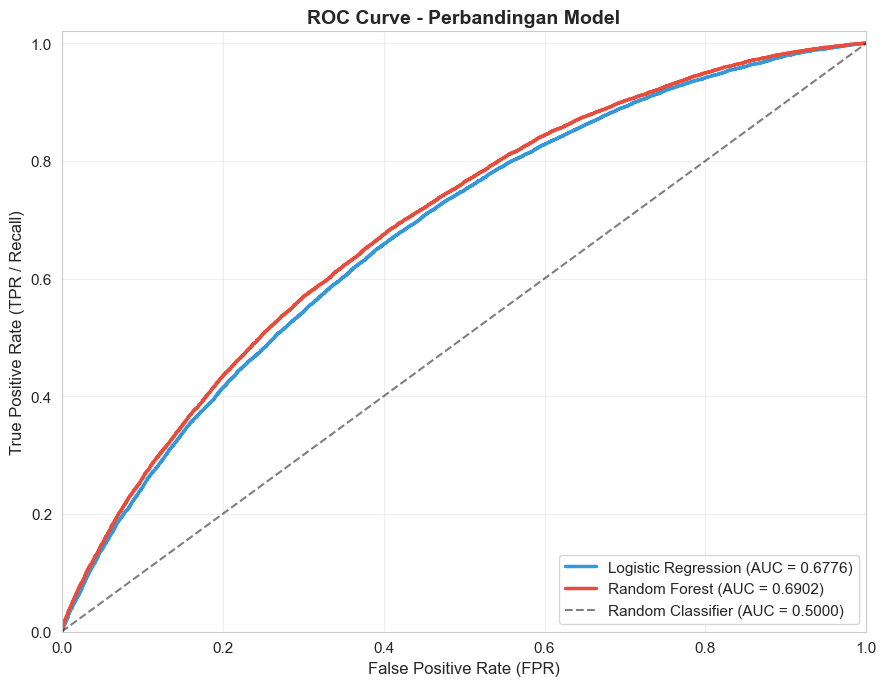

In [28]:
fig, ax = plt.subplots(figsize=(9, 7))

model_results = [
    (y_test_proba_lr, 'Logistic Regression', '#3498db'),
    (y_test_proba_rf, 'Random Forest', '#e74c3c')
]

for y_proba, name, color in model_results:
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {auc:.4f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier (AUC = 0.5000)')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
ax.set_title('ROC Curve - Perbandingan Model', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('09_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3 Feature Importance (Random Forest)

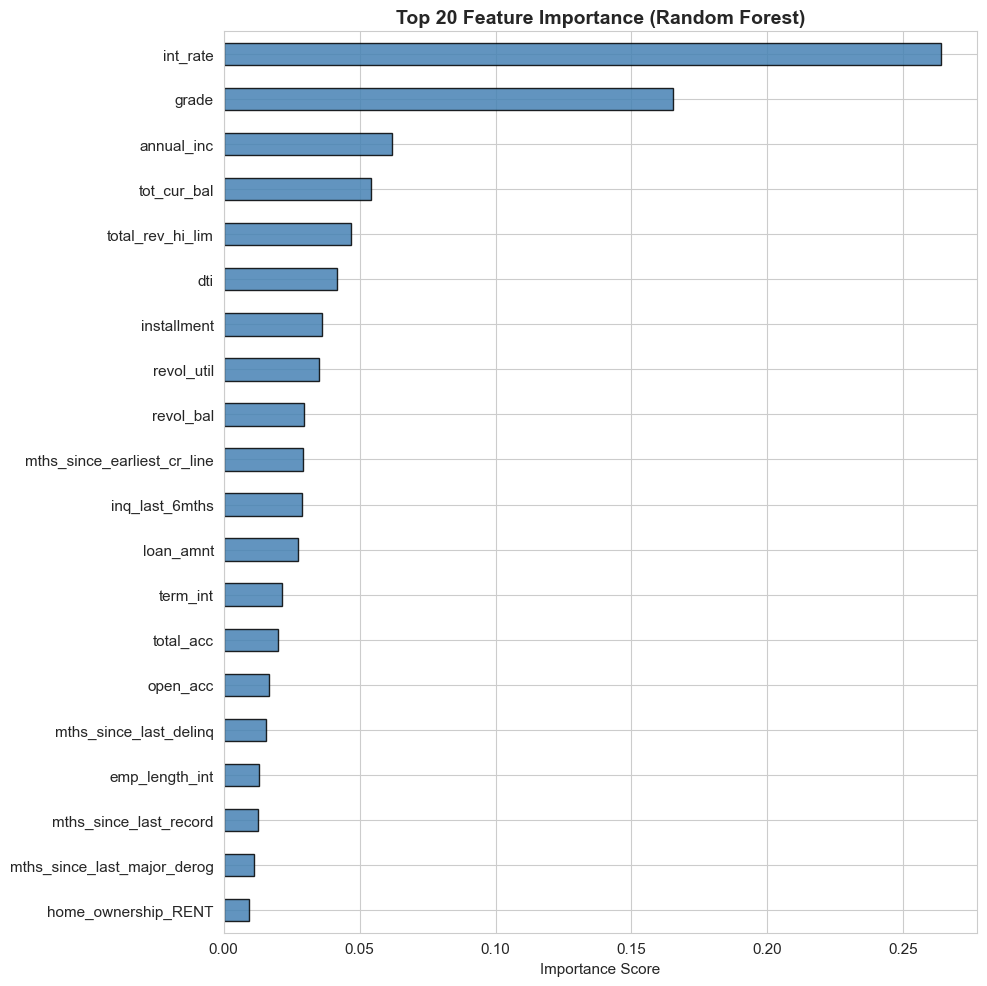

Top 10 Fitur Terpenting:
   1. int_rate                                 → 0.2639
   2. grade                                    → 0.1653
   3. annual_inc                               → 0.0619
   4. tot_cur_bal                              → 0.0542
   5. total_rev_hi_lim                         → 0.0470
   6. dti                                      → 0.0416
   7. installment                              → 0.0361
   8. revol_util                               → 0.0349
   9. revol_bal                                → 0.0297
  10. mths_since_earliest_cr_line              → 0.0293


In [29]:
# Feature importance dari Random Forest
feat_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=True)

# Plot top 20
plt.figure(figsize=(10, 10))
feat_imp_sorted.tail(20).plot(
    kind='barh', color='steelblue', edgecolor='black', alpha=0.85
)
plt.title('Top 20 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 Fitur Terpenting:")
for i, (feat, imp) in enumerate(feat_imp.sort_values(ascending=False).head(10).items(), 1):
    print(f"  {i:2d}. {feat:<40s} → {imp:.4f}")

## 6.4 Logistic Regression Coefficients

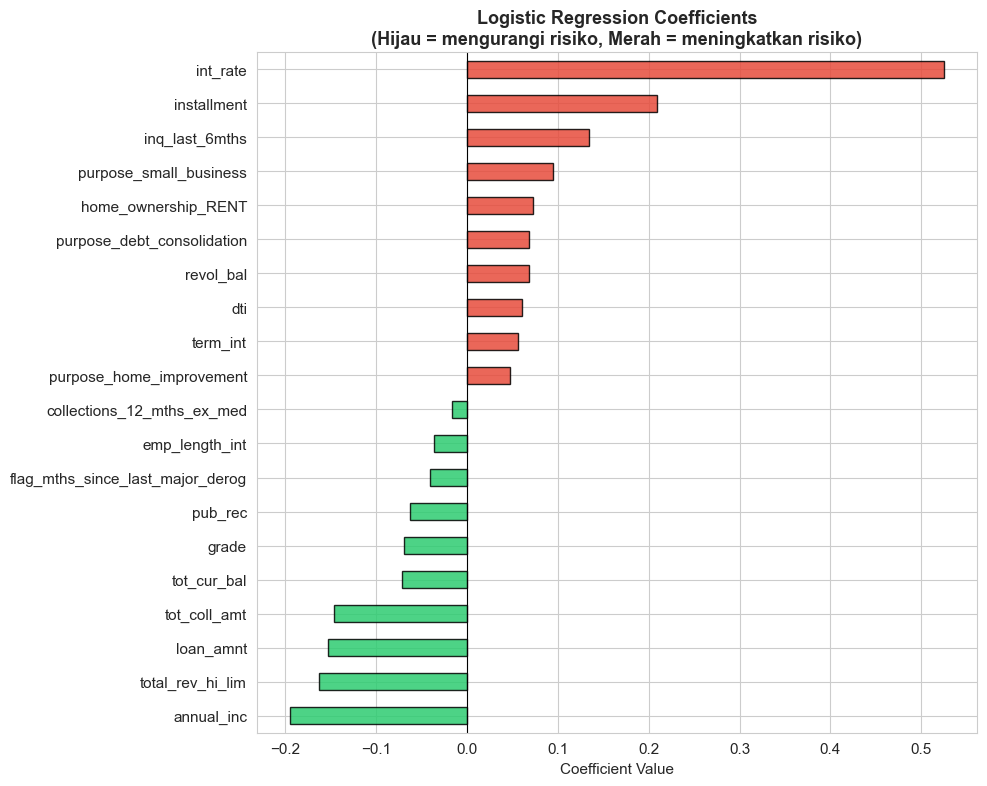

In [30]:
# Koefisien Logistic Regression
lr_coefs = pd.Series(lr_model.coef_[0], index=X_train.columns)
lr_coefs_sorted = lr_coefs.sort_values()

# Plot top & bottom 15
top_bottom = pd.concat([lr_coefs_sorted.head(10), lr_coefs_sorted.tail(10)])
colors_coef = ['#2ecc71' if c < 0 else '#e74c3c' for c in top_bottom]

plt.figure(figsize=(10, 8))
top_bottom.plot(kind='barh', color=colors_coef, edgecolor='black', alpha=0.85)
plt.title('Logistic Regression Coefficients\n(Hijau = mengurangi risiko, Merah = meningkatkan risiko)',
          fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('11_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.5 Ringkasan Perbandingan Model

         RINGKASAN PERBANDINGAN MODEL
   Metric  Logistic Regression  Random Forest
 Accuracy               0.6274         0.6314
Precision               0.1848         0.1892
   Recall               0.6275         0.6412
 F1-Score               0.2856         0.2922
  ROC-AUC               0.6776         0.6902


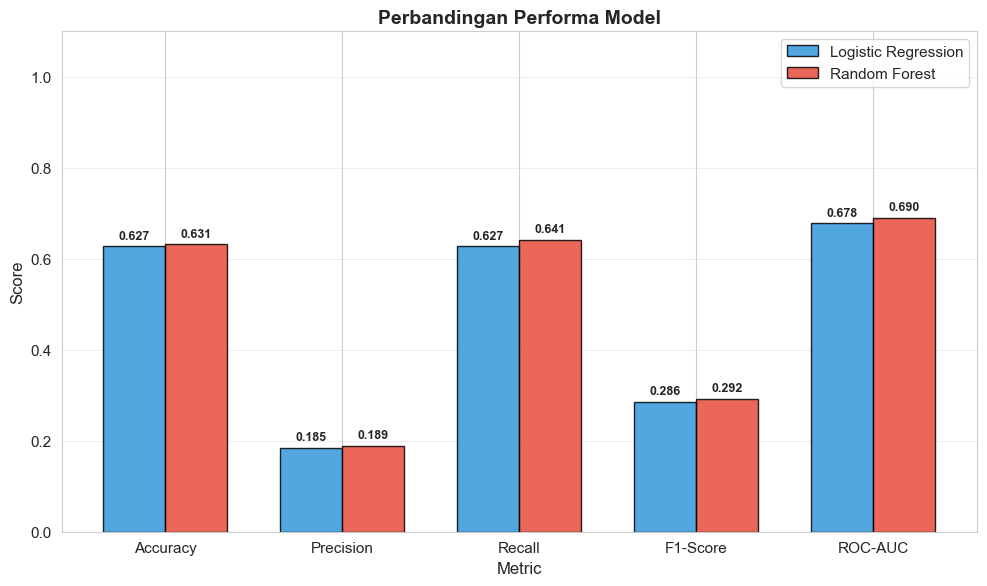

In [31]:
# Ringkasan perbandingan kedua model
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [
        accuracy_score(y_test, y_test_pred_lr),
        precision_score(y_test, y_test_pred_lr),
        recall_score(y_test, y_test_pred_lr),
        f1_score(y_test, y_test_pred_lr),
        roc_auc_score(y_test, y_test_proba_lr)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_test_pred_rf),
        precision_score(y_test, y_test_pred_rf),
        recall_score(y_test, y_test_pred_rf),
        f1_score(y_test, y_test_pred_rf),
        roc_auc_score(y_test, y_test_proba_rf)
    ]
})
summary[['Logistic Regression', 'Random Forest']] = summary[['Logistic Regression', 'Random Forest']].round(4)

print("=" * 65)
print("         RINGKASAN PERBANDINGAN MODEL")
print("=" * 65)
print(summary.to_string(index=False))
print("=" * 65)

# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(summary))
width = 0.35

bars1 = ax.bar(x - width/2, summary['Logistic Regression'], width,
               label='Logistic Regression', color='#3498db', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, summary['Random Forest'], width,
               label='Random Forest', color='#e74c3c', edgecolor='black', alpha=0.85)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan Performa Model', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(summary['Metric'], fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Tambahkan label nilai
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 7. KESIMPULAN

## Ringkasan Analisis

### Data Understanding & Preparation
- Dataset Lending Club (2007-2014) berisi **466.285 pinjaman** dengan **74 fitur** awal
- Setelah pembersihan, tersisa fitur-fitur yang relevan untuk prediksi di tahap origination (saat pengajuan pinjaman)
- **27 kolom dihapus** karena: data leakage (post-origination), identitas, all-null, atau redundan
- Target variable `bad_flag` menunjukkan **dataset imbalanced** dengan proporsi bad loan sekitar ~12%

### Insight dari EDA
- Peminjam dengan **grade lebih rendah** (D-G) memiliki **bad rate lebih tinggi**
- **Interest rate** dan **DTI** yang lebih tinggi berkorelasi positif dengan default
- **Annual income** yang lebih tinggi cenderung menurunkan risiko default
- Pinjaman untuk **small business** memiliki bad rate tertinggi

### Model Performance
- Kedua model (**Logistic Regression** dan **Random Forest**) telah dibangun dan dievaluasi
- Penggunaan `class_weight='balanced'` membantu menangani **imbalanced data**
- Evaluasi dilakukan menggunakan: **Accuracy, Precision, Recall, F1-Score, dan ROC-AUC**
- **ROC-AUC** adalah metrik utama karena mampu mengevaluasi kemampuan model dalam membedakan kelas

### Rekomendasi
1. Untuk produksi, pertimbangkan **threshold tuning** pada probabilitas prediksi
2. Bisa dicoba teknik **oversampling (SMOTE)** atau **undersampling** untuk meningkatkan recall
3. Model dapat ditingkatkan dengan **hyperparameter tuning** (GridSearch/RandomSearch)
4. Feature engineering tambahan (seperti rasio debt-to-income per kategori) bisa meningkatkan performa